# Social Media Text Preprocessing and Analysis

This notebook performs data cleaning and preprocessing for social media posts collected from Meta and Bluesky. The goal is to prepare high-quality text data for downstream NLP analyses, including sentiment analysis and topic modeling.

## Overview

The notebook includes the following steps:

1. **Data Loading**
   - Load raw post data from Meta and Bluesky.

2. **Language Filtering**
   - Detect the language of each post.
   - Retain only English posts.

3. **Text Cleaning and Normalization**
   - Convert text to lowercase.
   - Remove URLs, user mentions, hashtags, emojis, and common boilerplate phrases.
   - Remove extra whitespace and line breaks.

4. **Minimum Length Filtering**
   - Compute the length of cleaned text.
   - Remove posts with fewer than 10 characters.

5. **Dataset Summary**
   - Report the number of posts before and after preprocessing.
   - Calculate the number and proportion of removed posts for each platform.

## Outputs

- Cleaned Meta and Bluesky datasets.
- Summary table of original vs. cleaned post counts.
- Preprocessed text ready for downstream modeling.

# read the file 

In [ ]:
# set the file path
file = ('your file path here')

## meta full dataset

In [ ]:
# read the meta data
import pandas as pd
meta = pd.read_csv(file + 'meta_data.csv')
meta.head(2)

,ad_archive_id,page_id,page_name,ad_creation_time,ad_delivery_start_time,ad_delivery_stop_time,byline,ad_creative_bodies,ad_creative_link_titles,ad_creative_link_captions,ad_creative_link_descriptions,impressions,spend,currency,demographic_distribution,delivery_by_region,publisher_platforms,estimated_audience_size,languages
0,1113427194265921,292649794717694,The Bulwark,2025-09-28,2025-09-28,2025-09-29,Bulwark Media,Yesterday we moved on to the dysgenic portion ...,"Autism, MAHA, and the Face of God",thebulwark.com,"One part junk science, two parts incompetent g...","lower_bound: 0, upper_bound: 999","lower_bound: 0, upper_bound: 99",USD,"{""age"":""18-24"",""gender"":""female"",""__umapi_quer...","{""region"":""Alabama"",""__umapi_query_id"":""8qri3i...","facebook,instagram",lower_bound: 1000001,en
1,3091537204359777,11111618026,Union of Concerned Scientists,2025-09-25,2025-09-25,NaN,"UNION OF CONCERNED SCIENTISTS, INC.",⚠️ SCIENCE EMERGENCY: 2X MATCH AVAILABLE! ⚠️\r...,"DOUBLE YOUR IMPACT,DOUBLE YOUR IMPACT","ucs.org/donate,ucs.org/donate",NaN,"lower_bound: 9000, upper_bound: 9999","lower_bound: 500, upper_bound: 599",USD,"{""age"":""18-24"",""gender"":""female"",""__umapi_quer...","{""region"":""Alabama"",""__umapi_query_id"":""td34wn...","facebook,instagram",lower_bound: 1000001,en


In [ ]:
# meta['language'].value_counts()              # count
meta['languages'].value_counts(normalize=True) # percentage

,proportion
languages,
en,0.993193
es,0.003464
pt,0.000608
zh,0.000425
ar,0.000365
"es,en",0.000243
fr,0.000182
it,0.000182
vi,0.000182


## bluesky full dataset

In [ ]:
# read the bluesky data
bluesky = pd.read_csv(file + 'bluesky_data.csv')
bluesky.head(2)

,author,author_did,indexed_at,text,uri,cid
0,lynnc1955.bsky.social,did:plc:cpu5hfxtbhyszmle3mekejab,2025-08-03T22:14:21.505Z,"Gee, what would Canada do without americans te...",at://did:plc:cpu5hfxtbhyszmle3mekejab/app.bsky...,bafyreic7fo5xbxgi75dt7gxavznzcnthh6d7nnkupfayk...
1,democracyactionnet.bsky.social,did:plc:ivkxtqdth35x44yi627qdtjq,2025-07-23T03:03:07.341Z,The Trump administration has drafted a plan to...,at://did:plc:ivkxtqdth35x44yi627qdtjq/app.bsky...,bafyreichvhc5elu3nx6sjfnbrdpb3ob6r6aoqvpalc47p...


In [ ]:
# detect the langauge of "text" columns
# !pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 13.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=2d678f0aa4737658e324fbf892c77c6e84cc4292a89d7427a82f63c88c8a0438
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [ ]:
# detect the langauge of "text" columns
from langdetect import detect

def detect_lang(text):
    try:
        return detect(text)
    except:
        return None

bluesky['languages'] = bluesky['text'].astype(str).apply(detect_lang)
bluesky.head(2)

,author,author_did,indexed_at,text,uri,cid,languages
0,lynnc1955.bsky.social,did:plc:cpu5hfxtbhyszmle3mekejab,2025-08-03T22:14:21.505Z,"Gee, what would Canada do without americans te...",at://did:plc:cpu5hfxtbhyszmle3mekejab/app.bsky...,bafyreic7fo5xbxgi75dt7gxavznzcnthh6d7nnkupfayk...,en
1,democracyactionnet.bsky.social,did:plc:ivkxtqdth35x44yi627qdtjq,2025-07-23T03:03:07.341Z,The Trump administration has drafted a plan to...,at://did:plc:ivkxtqdth35x44yi627qdtjq/app.bsky...,bafyreichvhc5elu3nx6sjfnbrdpb3ob6r6aoqvpalc47p...,en


In [ ]:
bluesky['languages'].unique()

array(['en', 'fr', 'af', 'tl', 'pl', 'ro', 'es', 'de', 'vi', 'sv', 'it',
       'no', 'nl', 'da', 'so', 'pt', 'ca', None, 'hu', 'fi', 'et', 'lv',
       'id', 'cs', 'sq', 'bg', 'ja', 'sk'], dtype=object)

In [ ]:
# bluesky['language'].value_counts()              # count
bluesky['languages'].value_counts(normalize=True) # percentage

,proportion
languages,
en,0.990666
fr,0.001982
de,0.001564
it,0.000886
nl,0.000730
af,0.000626
da,0.000469
ro,0.000417
es,0.000365


# remove non-English posts

In [ ]:
# just keep english posts
meta_en = meta[meta['languages'] == 'en'][['ad_archive_id', 'ad_creative_bodies']]
meta_en.head(2)

,ad_archive_id,ad_creative_bodies
0,1113427194265921,Yesterday we moved on to the dysgenic portion ...
1,3091537204359777,⚠️ SCIENCE EMERGENCY: 2X MATCH AVAILABLE! ⚠️\r...


In [ ]:
# just keep english posts
bluesky_en = bluesky[bluesky['languages'] == 'en'][['author_did', 'text']]

In [ ]:
bluesky_en.head(2)

,author_did,text
0,did:plc:cpu5hfxtbhyszmle3mekejab,"Gee, what would Canada do without americans te..."
1,did:plc:ivkxtqdth35x44yi627qdtjq,The Trump administration has drafted a plan to...


# clean the "text": remove emoji, URLs, hashtags

In [ ]:
import re

def clean_text(text):

    if isinstance(text, str):

        # 1. lowercase
        text = text.lower()

        # 2. remove URLs
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

        # 3. remove @mentions
        text = re.sub(r'@\w+', '', text)

        # 4. remove hashtags completely
        text = re.sub(r'#', '', text)

        # 5. remove emojis
        emoji_pattern = re.compile("["
                                   u"\U0001F600-\U0001F64F"
                                   u"\U0001F300-\U0001F5FF"
                                   u"\U0001F680-\U0001F6FF"
                                   u"\U0001F700-\U0001F77F"
                                   u"\U0001F780-\U0001F7FF"
                                   u"\U0001F800-\U0001F8FF"
                                   u"\U0001F900-\U0001F9FF"
                                   u"\U0001FA00-\U0001FAFF"
                                   u"\U00002702-\U000027B0"
                                   u"\U000024C2-\U0001F251"
                                   "]+", flags=re.UNICODE)
        text = emoji_pattern.sub(r'', text)

        # 6. remove boilerplate phrases (common promo language)
        boilerplate_patterns = [
            r'click here',
            r'learn more',
            r'for more info',
            r'join us',
            r'sign up',
            r'subscribe',
            r'visit our website',
        ]
        for pattern in boilerplate_patterns:
            text = re.sub(pattern, '', text)

        # 7. remove extra whitespace / line breaks
        text = re.sub(r'\s+', ' ', text).strip()

        return text

    else:
        # Handle non-string values (e.g., return empty string)
        return ''

In [ ]:
# Apply the cleaning function to the 'text' column
meta_en['clean_text'] = meta_en['ad_creative_bodies'].apply(clean_text)
meta_en.head(2)

,ad_archive_id,ad_creative_bodies,clean_text
0,1113427194265921,Yesterday we moved on to the dysgenic portion ...,yesterday we moved on to the dysgenic portion ...
1,3091537204359777,⚠️ SCIENCE EMERGENCY: 2X MATCH AVAILABLE! ⚠️\r...,science emergency: 2x match available! trump i...


In [ ]:
bluesky_en['clean_text'] = bluesky_en['text'].apply(clean_text)
bluesky_en.head(2)

,author_did,text,clean_text
0,did:plc:cpu5hfxtbhyszmle3mekejab,"Gee, what would Canada do without americans te...","gee, what would canada do without americans te..."
1,did:plc:ivkxtqdth35x44yi627qdtjq,The Trump administration has drafted a plan to...,the trump administration has drafted a plan to...


# minimum length filter

In [ ]:
meta_en['text_len'] = meta_en['clean_text'].str.len()
meta_clean = meta_en[meta_en['text_len'] >= 10]
meta_clean.head(2)

,ad_archive_id,ad_creative_bodies,clean_text,text_len
0,1113427194265921,Yesterday we moved on to the dysgenic portion ...,yesterday we moved on to the dysgenic portion ...,274
1,3091537204359777,⚠️ SCIENCE EMERGENCY: 2X MATCH AVAILABLE! ⚠️\r...,science emergency: 2x match available! trump i...,988


In [ ]:
# compute the text length
bluesky_en['text_len'] = bluesky_en['clean_text'].str.len()
bluesky_clean = bluesky_en[bluesky_en['text_len'] >= 10]
bluesky_clean.head(2)

/tmp/ipython-input-2465798393.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bluesky_en['text_len'] = bluesky_en['clean_text'].str.len()


,author_did,text,clean_text,text_len
0,did:plc:cpu5hfxtbhyszmle3mekejab,"Gee, what would Canada do without americans te...","gee, what would canada do without americans te...",265
1,did:plc:ivkxtqdth35x44yi627qdtjq,The Trump administration has drafted a plan to...,the trump administration has drafted a plan to...,202


In [ ]:
# save the cleaned data
meta_clean.to_csv(file + 'meta_clean.csv', index=False)
bluesky_clean.to_csv(file + 'bluesky_clean.csv', index=False)

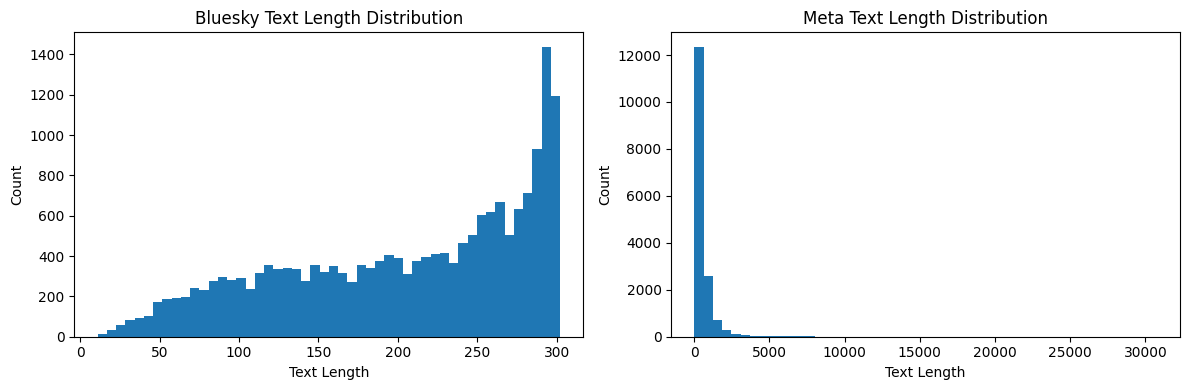

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

# Bluesky
plt.subplot(1,2,1)
plt.hist(bluesky_en['text_len'], bins=50)
plt.title('Bluesky Text Length Distribution')
plt.xlabel('Text Length')
plt.ylabel('Count')

# Meta
plt.subplot(1,2,2)
plt.hist(meta_en['text_len'], bins=50)
plt.title('Meta Text Length Distribution')
plt.xlabel('Text Length')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

**Bluesky posts are generally longer and more evenly distributed, while Meta posts are mostly very short with a few extremely long outliers.**

# report how many posts were removed

In [ ]:
meta_original = len(meta)
bluesky_original = len(bluesky)

meta_cleaned = len(meta_clean)
bluesky_cleaned = len(bluesky_clean)

meta_removed = meta_original - meta_cleaned
bluesky_removed = bluesky_original - bluesky_cleaned

meta_removed_prop = meta_removed / meta_original
bluesky_removed_prop = bluesky_removed / bluesky_original

summary_table = pd.DataFrame({
    'Platform': ['Meta', 'Bluesky'],
    'Total Posts (Original)': [meta_original, bluesky_original],
    'Posts After Cleaning': [meta_cleaned, bluesky_cleaned],
    'Posts Removed': [meta_removed, bluesky_removed],
    'Removal Rate': [meta_removed_prop, bluesky_removed_prop]
})

print("Table 1. Summary of Post Counts Before and After Cleaning")
summary_table

Table 1. Summary of Post Counts Before and After Cleaning


,Platform,Total Posts (Original),Posts After Cleaning,Posts Removed,Removal Rate
0,Meta,17026,16333,693,0.040702
1,Bluesky,19182,18987,195,0.010166


# next step

to-do: 
- filter out texts with irrelavant topic
- ilters out texts which do not have an
existing claim. We will use an LLM to place each
text into the category of "Claim" or "No Claim",
additionally using knowledge of claim-associated
terms such as causal verbs and declarative asser-
tions to filter each text into the proper category.

#